# Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Missing Value

In [2]:
df = pd.read_csv("train.csv")

print("=== INFO DATASET ===")
print(df.info())
display(df.head())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# HAPUS KOLOM ID
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
    print("Kolom 'Id' berhasil dihapus.")
else:
    print("Kolom 'Id' tidak ditemukan.")

Kolom 'Id' berhasil dihapus.


In [4]:
#CEK DUPLIKAT
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah total baris duplikat: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    print("Baris-baris duplikat (menampilkan semua instance duplikat):")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))
else:
    print("Tidak ada baris duplikat dalam DataFrame.")

Jumlah total baris duplikat: 0
Tidak ada baris duplikat dalam DataFrame.


In [5]:
# CEK MISSING VALUE
print("\n MISSING VALUE SEBELUM IMPUTASI")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing)


 MISSING VALUE SEBELUM IMPUTASI


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [6]:
cols_fill_none = [
    'PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu',
    'GarageType','GarageFinish','GarageQual','GarageCond','BsmtExposure',
    'BsmtFinType2','BsmtQual','BsmtCond','BsmtFinType1','Electrical'
]

for col in cols_fill_none:
    df[col] = df[col].fillna('None')

cols_fill_zero = ['LotFrontage','GarageYrBlt','MasVnrArea']
for col in cols_fill_zero:
    df[col] = df[col].fillna(0)

print("\n MISSING VALUE SELESAI")
display(df.isnull().sum()[df.isnull().sum() > 0])


 MISSING VALUE SELESAI


,0


# Outlier

In [7]:
df_before = df.copy()

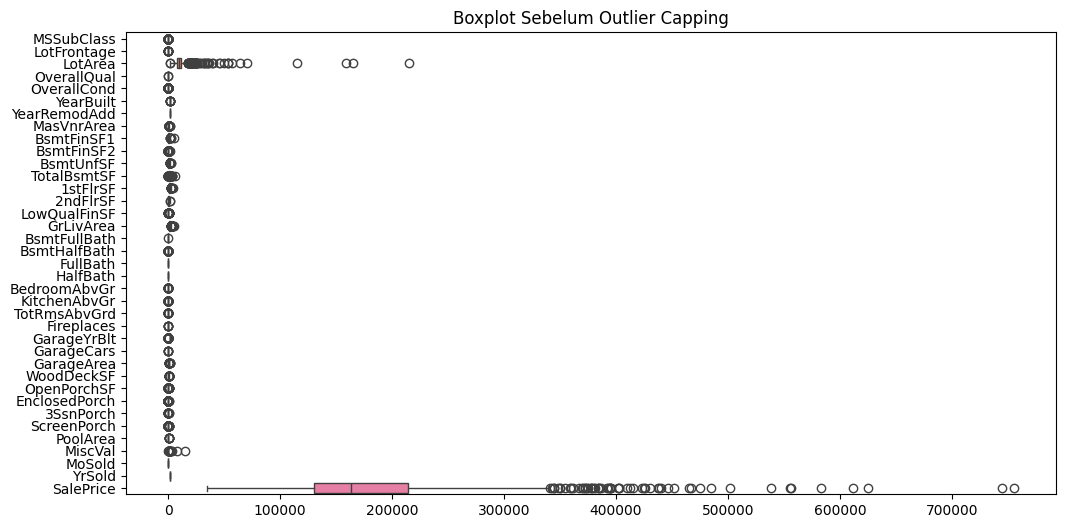

In [8]:
# visualisasi before outlier handling

import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# --- BOXPlot BEFORE ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_before[numerical_cols], orient='h')
plt.title("Boxplot Sebelum Outlier Capping")
plt.show()

In [9]:
print("\n PROSES OUTLIER CAPPING")

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Aman dari error, hanya remove jika Id masih ada
if 'Id' in numerical_cols:
  numerical_cols.remove('Id')

def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        print(f"\nKolom: {col}")
        print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
        print(f"Batas bawah: {lower:.2f}, batas atas: {upper:.2f}")

        df[col] = np.where(df[col] < lower, lower,
                           np.where(df[col] > upper, upper, df[col]))
    return df

df = cap_outliers(df, numerical_cols)
print("\n Outlier capping selesai.")


 PROSES OUTLIER CAPPING

Kolom: MSSubClass
Q1=20.00, Q3=70.00, IQR=50.00
Batas bawah: -55.00, batas atas: 145.00

Kolom: LotFrontage
Q1=42.00, Q3=79.00, IQR=37.00
Batas bawah: -13.50, batas atas: 134.50

Kolom: LotArea
Q1=7553.50, Q3=11601.50, IQR=4048.00
Batas bawah: 1481.50, batas atas: 17673.50

Kolom: OverallQual
Q1=5.00, Q3=7.00, IQR=2.00
Batas bawah: 2.00, batas atas: 10.00

Kolom: OverallCond
Q1=5.00, Q3=6.00, IQR=1.00
Batas bawah: 3.50, batas atas: 7.50

Kolom: YearBuilt
Q1=1954.00, Q3=2000.00, IQR=46.00
Batas bawah: 1885.00, batas atas: 2069.00

Kolom: YearRemodAdd
Q1=1967.00, Q3=2004.00, IQR=37.00
Batas bawah: 1911.50, batas atas: 2059.50

Kolom: MasVnrArea
Q1=0.00, Q3=164.25, IQR=164.25
Batas bawah: -246.38, batas atas: 410.62

Kolom: BsmtFinSF1
Q1=0.00, Q3=712.25, IQR=712.25
Batas bawah: -1068.38, batas atas: 1780.62

Kolom: BsmtFinSF2
Q1=0.00, Q3=0.00, IQR=0.00
Batas bawah: 0.00, batas atas: 0.00

Kolom: BsmtUnfSF
Q1=223.00, Q3=808.00, IQR=585.00
Batas bawah: -654.50, bat

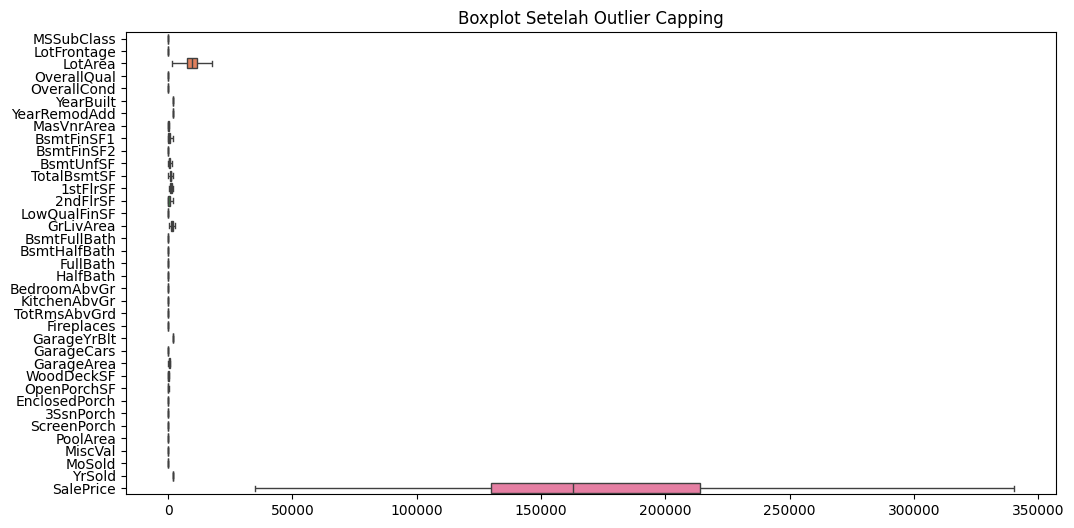

In [10]:
# Visualisasi after outlier handling

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols], orient='h')
plt.title("Boxplot Setelah Outlier Capping")
plt.show()

# One Hot Encoding

In [11]:
print("\n ONE-HOT ENCODING")
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Kolom kategorikal yang di-encode:")
print(cat_cols)

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("\n Data setelah encoding:")
display(df.head())


 ONE-HOT ENCODING
Kolom kategorikal yang di-encode:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

 Data setelah encoding:


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60.0,65.0,8450.0,7.0,5.0,2003.0,2003.0,196.0,706.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1,20.0,80.0,9600.0,6.0,7.5,1976.0,1976.0,0.0,978.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2,60.0,68.0,11250.0,7.0,5.0,2001.0,2002.0,162.0,486.0,0.0,...,False,False,False,False,True,False,False,False,True,False
3,70.0,60.0,9550.0,7.0,5.0,1915.0,1970.0,0.0,216.0,0.0,...,False,False,False,False,True,False,False,False,False,False
4,60.0,84.0,14260.0,8.0,5.0,2000.0,2000.0,350.0,655.0,0.0,...,False,False,False,False,True,False,False,False,True,False


# Split Fitur & Target dan Train Test Split

In [12]:
print("\n SPLIT FITUR DAN TARGET")

y = df['SalePrice']
X = df.drop('SalePrice', axis=1)

print("X (fitur) shape:", X.shape)
print("y (target) shape:", y.shape)


 SPLIT FITUR DAN TARGET
X (fitur) shape: (1460, 260)
y (target) shape: (1460,)


In [13]:
# SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nSplit selesai:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


Split selesai:
X_train: (1168, 260)
X_test : (292, 260)


# Normalisasi (ANN)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nNormalisasi selesai.")
display(X_train_df.head())
display(X_test_df.head())

X_train = X_train_scaled
X_test = X_test_scaled


Normalisasi selesai.


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-0.933485,0.396268,-0.369609,-0.825200,0.470430,-0.458161,-1.346063,-0.678804,1.111760,0.0,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
1,0.135447,0.066748,-0.527046,-0.090571,1.514042,0.719895,0.439214,-0.678804,-1.023323,0.0,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
2,-0.666252,0.306399,-0.264185,-0.825200,1.514042,-1.996178,-1.683818,-0.678804,-1.023323,0.0,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
3,-0.131786,0.096704,-0.705176,-0.825200,1.514042,-1.112636,-1.683818,1.198235,0.294315,0.0,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
4,-0.131786,-0.202860,-1.320382,-0.825200,0.470430,-1.538045,-1.683818,-0.678804,-0.518499,0.0,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-0.933485,0.396268,-0.365694,-0.090571,2.035848,-0.261818,0.873470,-0.678804,0.511991,0.0,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
1,0.135447,1.235046,0.708680,1.378687,-0.573183,0.752619,0.487465,2.017578,1.366487,0.0,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
2,-0.666252,-0.023121,-0.213011,-0.825200,0.470430,-1.439874,-1.683818,-0.678804,-1.023323,0.0,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
3,-0.131786,-0.202860,-1.320382,-0.090571,1.514042,-0.785399,-1.683818,-0.678804,-0.099356,0.0,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636
4,-0.933485,0.965439,0.888208,2.113316,-0.573183,1.178028,1.114724,-0.157404,1.343330,0.0,...,-0.058621,-0.058621,-0.300948,-0.041416,0.39262,-0.058621,-0.077648,-0.125109,0.46002,-0.302636


In [15]:
# LogTransformation
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Gunakan y_train_log dan y_test_log untuk pelatihan model ANN
print("Variabel target telah ditransformasi menjadi logaritma (y_train_log, y_test_log).")

Variabel target telah ditransformasi menjadi logaritma (y_train_log, y_test_log).


# Pembangunan Model ANN

In [16]:
# Penyempurnaan Model ANN
ann = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dense(1)
])

ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# EARLY STOPPING → otomatis berhenti jika model tidak membaik
estop = EarlyStopping(
    monitor='val_loss',
    patience=35,
    restore_best_weights=True
)

In [18]:
# TRAINING MODEL
history_best = ann.fit(
    X_train, y_train_log,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[estop],
    verbose=1
)

Epoch 1/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 137.7036 - mae: 11.6843 - val_loss: 107.2976 - val_mae: 10.3463
Epoch 2/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 90.5599 - mae: 9.4443 - val_loss: 36.0382 - val_mae: 5.9238
Epoch 3/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 28.3708 - mae: 5.1420 - val_loss: 4.4345 - val_mae: 1.9206
Epoch 4/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4044 - mae: 0.9721 - val_loss: 0.9724 - val_mae: 0.8155
Epoch 5/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2051 - mae: 0.3514 - val_loss: 0.2528 - val_mae: 0.4123
Epoch 6/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1090 - mae: 0.2503 - val_loss: 0.0434 - val_mae: 0.1430
Epoch 7/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0885 - mae: 0.2225 - val_loss: 0.0691 - val_mae: 0.2085
Epoch 8/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0676 - mae: 0.2009 - val_loss: 0.0507 - val_mae: 0.1716
Epoch 9/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - l

In [19]:
# Prediksi
y_pred_ann_log = ann.predict(X_test)
y_pred_ann = np.expm1(y_pred_ann_log)

print("\n=== 10 Prediksi Pertama (ANN) ===")
for i in range(10):
    print(f"Actual: {y_test.iloc[i]:,.0f}   |   Predicted: {float(y_pred_ann[i]):,.0f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

=== 10 Prediksi Pertama (ANN) ===
Actual: 154,500   |   Predicted: 144,228
Actual: 325,000   |   Predicted: 273,404
Actual: 115,000   |   Predicted: 115,667
Actual: 159,000   |   Predicted: 170,116
Actual: 315,500   |   Predicted: 283,618
Actual: 75,500   |   Predicted: 83,889
Actual: 311,500   |   Predicted: 223,248
Actual: 146,000   |   Predicted: 145,659
Actual: 84,500   |   Predicted: 80,859
Actual: 135,500   |   Predicted: 135,681


/tmp/ipython-input-3010880117.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Actual: {y_test.iloc[i]:,.0f}   |   Predicted: {float(y_pred_ann[i]):,.0f}")


In [20]:
# DataFrame perbandingan actual vs predicted
df_pred_ann = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_ann.squeeze()
})

print("\n=== DataFrame Perbandingan Actual vs Predicted (ANN) ===")
display(df_pred_ann.head(10))


=== DataFrame Perbandingan Actual vs Predicted (ANN) ===


,Actual,Predicted
0,154500.0,144228.06250
1,325000.0,273403.90625
2,115000.0,115667.37500
3,159000.0,170115.87500
4,315500.0,283617.59375
5,75500.0,83889.28125
6,311500.0,223248.40625
7,146000.0,145658.87500
8,84500.0,80859.28125
9,135500.0,135680.78125


In [21]:
# Evaluasi ANN
mse_ann = mean_squared_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mse_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print("=== HASIL MODEL ANN ===")
print(f"MSE   : {mse_ann:.2f}")
print(f"RMSE  : {rmse_ann:.2f}")
print(f"R²    : {r2_ann:.4f}")

=== HASIL MODEL ANN ===
MSE   : 571132973.93
RMSE  : 23898.39
R²    : 0.8832


# Random Forest

In [22]:
# split model

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# Model Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [24]:
# latih model

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [25]:
# Prediksi dan Evaluasi Model
y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== EVALUASI RANDOM FOREST ===")
print(f"MSE   : {mse_rf:,.2f}")
print(f"RMSE  : {rmse_rf:,.2f}")
print(f"MAE   : {mae_rf:,.2f}")
print(f"R²    : {r2_rf:.4f}")

=== EVALUASI RANDOM FOREST ===
MSE   : 422,202,806.04
RMSE  : 20,547.57
MAE   : 14,872.15
R²    : 0.9136


In [26]:
#   ACTUAL VS PREDIKSI RF

df_compare_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

print("=== 10 Data Pertama: Actual vs Predicted (Random Forest) ===")
display(df_compare_rf.head(10))

=== 10 Data Pertama: Actual vs Predicted (Random Forest) ===


,Actual,Predicted
0,154500.0,140794.873333
1,325000.0,305213.518333
2,115000.0,116411.666667
3,159000.0,155356.180000
4,315500.0,296907.433333
5,75500.0,83429.110000
6,311500.0,213479.163333
7,146000.0,153252.110000
8,84500.0,84032.493333
9,135500.0,131008.326667


In [27]:
#Fitur paling Berpengaruh
importances = rf.feature_importances_
feature_names = X.columns

# Buat DataFrame
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("=== 20 Fitur Paling Berpengaruh ===")
display(fi_df.head(20))


=== 20 Fitur Paling Berpengaruh ===


,Feature,Importance
3,OverallQual,0.600351
15,GrLivArea,0.121239
11,TotalBsmtSF,0.036891
8,BsmtFinSF1,0.026551
25,GarageCars,0.022357
26,GarageArea,0.021490
12,1stFlrSF,0.017545
2,LotArea,0.015268
5,YearBuilt,0.012550
6,YearRemodAdd,0.007374


# Cek Overfitting

In [28]:
print('=== Overfitting Check ANN ===')
# For ANN, predict log-transformed values first, then inverse transform for R2 score against original y_train/y_test
# Make sure to use X_train_scaled and X_test_scaled for ANN predictions
# Calculate R2 for training data
y_train_pred_log = ann.predict(X_train_scaled)
y_train_pred_ann = np.expm1(y_train_pred_log)
print('Train R2:', r2_score(y_train, y_train_pred_ann))

# Calculate R2 for test data
y_test_pred_log = ann.predict(X_test_scaled)
y_test_pred_ann = np.expm1(y_test_pred_log)
print('Test R2 :', r2_score(y_test, y_test_pred_ann))

print('\n=== Overfitting Check RF ===')
print('Train R2:', r2_score(y_train, rf.predict(X_train)))
print('Test R2 :', r2_score(y_test, rf.predict(X_test)))

=== Overfitting Check ANN ===
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train R2: 0.932604528666674
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Test R2 : 0.8831859738080732

=== Overfitting Check RF ===
Train R2: 0.984084268251346
Test R2 : 0.9136467129471979


# Visualisasi

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


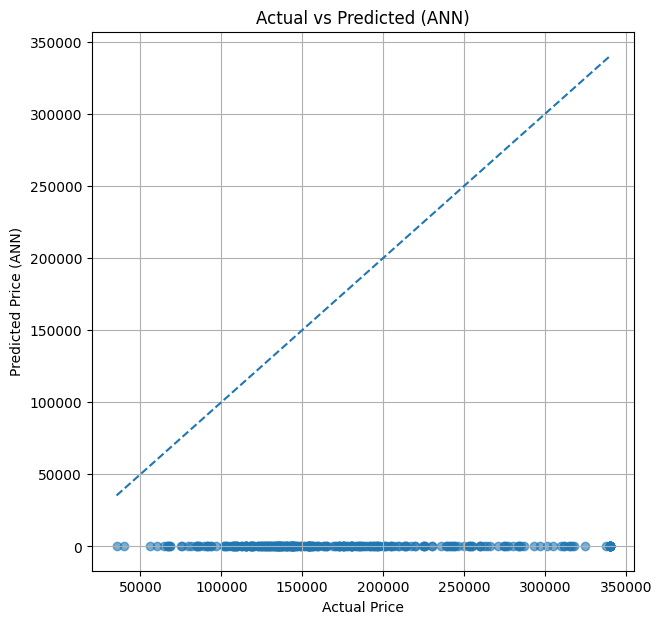

In [29]:
# Scatterplot Aktual vs Prediksi ANN

y_pred_ann = ann.predict(X_test).flatten()

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_ann, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price (ANN)")
plt.title("Actual vs Predicted (ANN)")
plt.grid(True)
plt.show()


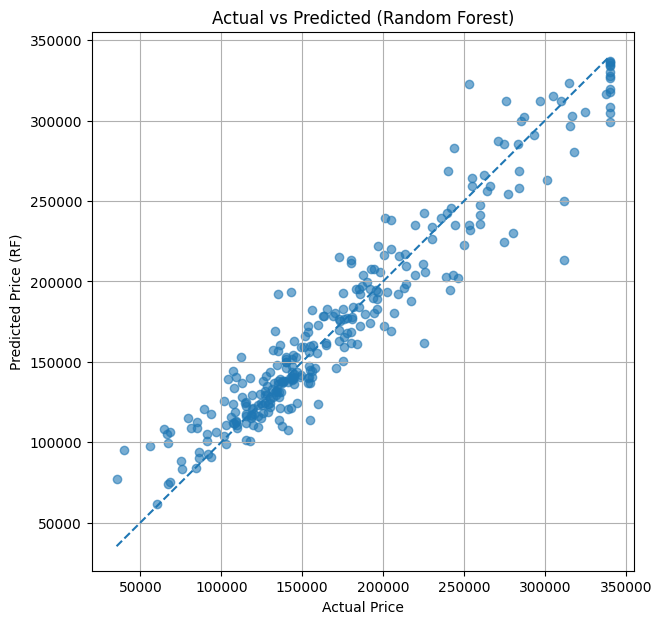

In [30]:
# Scatterplot Prediksi vs Aktual Random Forest

y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price (RF)")
plt.title("Actual vs Predicted (Random Forest)")
plt.grid(True)
plt.show()
